<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2

#### Sebastián Ceballes


# Consigna
En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de B bits en un rango de  ±VF
 Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a fs Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

frecuencia f0
 arbitraria, por ejemplo f0=fS/N=Δf
 
energía normalizada, es decir energía (o varianza) unitaria
Con respecto a los parámetros de la secuencia de ruido, diremos que:

será de carácter aditivo, es decir la señal que entra al ADC será sR=s+n
. Siendo n
 la secuencia que simula la interferencia, y s
 la senoidal descrita anteriormente.
La potencia del ruido será Pn=kn.Pq
 W siendo el factor k una escala para la potencia del ruido de cuantización Pq=q212
.
finalmente, n
 será incorrelado y Gaussiano.
El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000
 Hz y tendrá un rango analógico de ±VF=2
 Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
.
b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
. Discutir los resultados respecto a lo obtenido en a).

Bonus:

💎 Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada. (Ver Holton. DSP Principles and App. 6.7 ADC Quantization pag. 387 )
🤯 Calcular el SNR de la señal cuantizada para cada caso y armar una tabla comparativa.


# Resolución
# Simulación de un ADC con Ruido Aditivo

En esta sección, modelaremos el proceso de digitalización de una señal utilizando un Convertidor Analógico-Digital (ADC). A diferencia de un modelo ideal, incorporaremos una fuente de ruido aditivo Gaussiano ($n$) a la señal original ($s$) antes del muestreo, de modo que la entrada al ADC sea $s_R = s + n$. 

El objetivo es visualizar el impacto conjunto del ruido externo y el error inherente de cuantización ($P_q$) mediante una relación de potencias controlada por el factor $k_n$. Para esta primera prueba, configuraremos un ADC de 4 bits con un rango de $\pm 2.0$ V, donde las potencias del ruido externo y de cuantización son iguales ($k_n = 1$), analizando el comportamiento en el dominio del tiempo, su espectro de frecuencias y la distribución estadística del error.

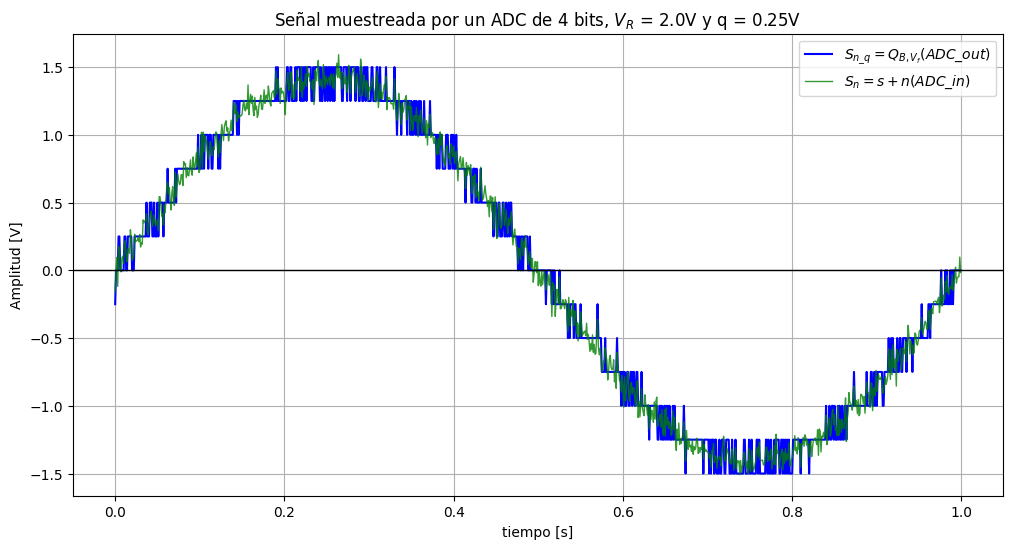

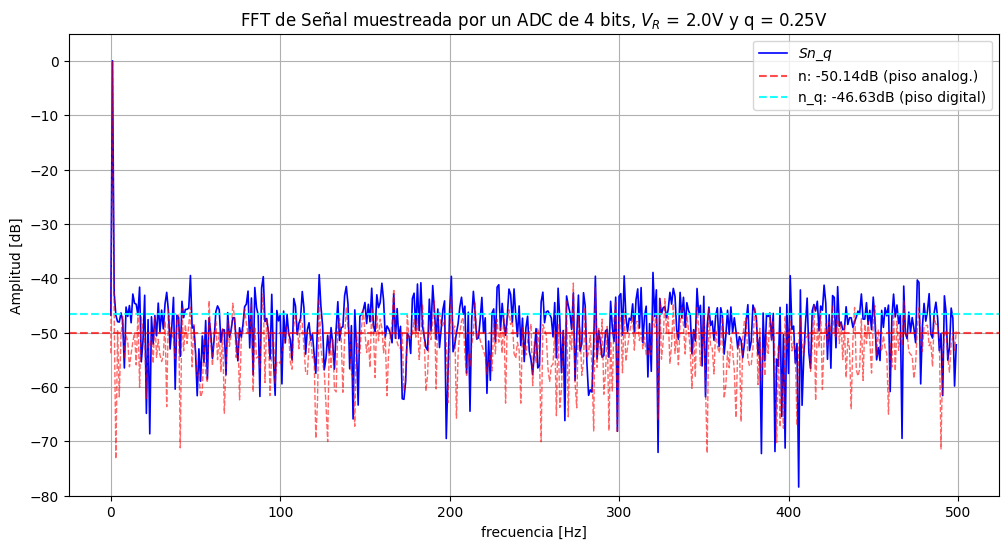

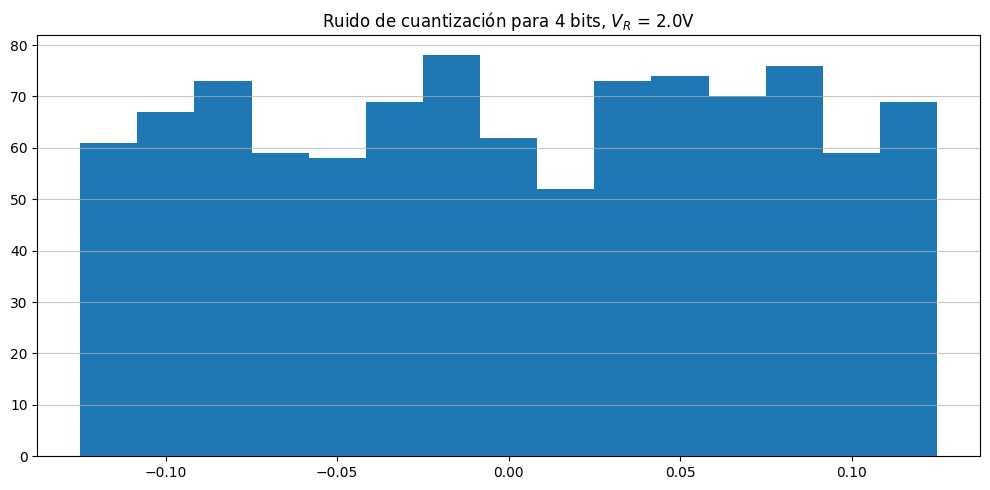

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- DEFINICION CTES ----------------------
fs = 1000 # Frecuencia muestreo (Hz)
N = 1000  # Cant. muestras
vmax = np.sqrt(2) # Amp max para varianza unitaria (1W)
dc = 0 # Offset
ff = fs / N # Frecuencia sinusoidal (Hz) -> delta_f
ph = 0 # rad

# Parámetros del ADC
n_bits = 4
Vfs = 2.0
q = (2 * Vfs) / (2 ** n_bits)
k_n = 1

# ------------------------- FUNCIONES -------------------------
def gen_sin(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """Generador de señal senoidal"""
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_fft(senial):
    fft_out = np.fft.fft(senial)
    fft_abs = np.abs(fft_out[:N//2]) * (2/N)
    frecuencias = np.arange(N//2) * (fs/N)
    return frecuencias, fft_abs

# ------------------------ MAIN SCRIPT ------------------------
# 1. Generación de la señal original
t, s = gen_sin(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# 2. Definición del ruido según k_n y paso de cuantización
P_q = (q**2) / 12
P_n = k_n * P_q
sigma = np.sqrt(P_n)

# 3. Suma de ruido y proceso de cuantización
n = np.random.normal(scale=sigma, size=len(t))
sn = s + n
sn_cuantizada = np.round(sn/q) * q
n_q = sn_cuantizada - sn  # Ruido de cuantización resultante

# 4. Análisis en el dominio de la frecuencia (Normalización respecto al máximo)
freq, sn_fft_abs = mi_fft(sn)
ref = np.max(sn_fft_abs)
sn_fft_dB = 20 * np.log10(sn_fft_abs / ref + 1e-12)

freq, sn_cuantizada_fft_abs = mi_fft(sn_cuantizada)
sn_cuantizada_fft_dB = 20 * np.log10(sn_cuantizada_fft_abs / ref + 1e-12)

# Cálculo de los pisos de ruido (promedio de la potencia lineal excluyendo DC y f0)
piso_analog_lineal = np.mean((sn_fft_abs[2:] / ref)**2)
piso_analog_dB = 10 * np.log10(piso_analog_lineal)

piso_digital_lineal = np.mean((sn_cuantizada_fft_abs[2:] / ref)**2)
piso_digital_dB = 10 * np.log10(piso_digital_lineal)

# ------------------------ GRÁFICOS ------------------------
plt.close("all")
titulo_base = f"ADC de {n_bits} bits, $V_R$ = {Vfs}V y q = {q}V"

# Figura 1: Dominio del Tiempo
plt.figure(1, figsize=(12, 6))
plt.plot(t, sn_cuantizada, color="blue", linewidth=1.5, label="$S_{n\_q} = Q_{B,V_f}(ADC\_out)$")
plt.plot(t, sn, color="green", linewidth=1, alpha=0.8, label="$S_n = s+n (ADC\_in)$")
plt.title(f"Señal muestreada por un {titulo_base}")
plt.xlabel("tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.axhline(0, color="black", linewidth=1)
plt.grid(True)
plt.legend(loc='upper right')

# Figura 2: Espectro de Magnitud
plt.figure(2, figsize=(12, 6))
plt.plot(freq, sn_cuantizada_fft_dB, color="blue", linewidth=1.2, label="$Sn\_q$")
plt.plot(freq, sn_fft_dB, color="red", linestyle="--", linewidth=1, alpha=0.6)

# Pisos de ruido horizontales
plt.axhline(piso_analog_dB, color="red", linestyle="--", alpha=0.7, 
            label=f"n: {piso_analog_dB:.2f}dB (piso analog.)")
plt.axhline(piso_digital_dB, color="cyan", linestyle="--", alpha=0.9, 
            label=f"n_q: {piso_digital_dB:.2f}dB (piso digital)")

plt.title(f"FFT de Señal muestreada por un {titulo_base}")
plt.xlabel("frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.ylim([-80, 5])
plt.grid(True)
plt.legend(loc='upper right')

# Figura 3: Histograma
plt.figure(3, figsize=(10, 5))
plt.hist(n_q, bins=15, color="tab:blue")
plt.title(f"Ruido de cuantización para {n_bits} bits, $V_R$ = {Vfs}V")
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()


## Análisis de Resolución (B) y Relación de Ruido (kn)

Al variar la cantidad de bits ($B$) y el factor de escala del ruido analógico ($k_n$), se altera el balance de potencias entre el ruido que ya posee la señal y el error introducido por el ADC:

* **Impacto de $k_n$ (Relación Ruido Analógico/Cuantización):**
  * **$k_n = 0.1$:** El ruido de cuantización domina ($P_q > P_n$). En el espectro, el piso de ruido digital estará marcadamente por encima del piso analógico original.
  * **$k_n = 1$:** Ambas potencias de ruido son idénticas. Al sumarse (por ser incorreladas), la potencia total de ruido se duplica. En el espectro, esto se refleja como una separación exacta de **3 dB** entre el piso analógico y el digital.
  * **$k_n = 10$:** El ruido analógico es el dominante. Como vimos previamente, el ADC simplemente digitaliza el ruido existente y el piso digital se superpone casi por completo al analógico (separación de ~0.41 dB).
* **Impacto de $B$ (Resolución):**
  * A medida que aumentamos los bits de **4 a 8 y 16**, el paso de cuantización $q$ se reduce drásticamente de forma exponencial ($q \propto 2^{-B}$). 
  * Esto empuja el piso de ruido de cuantización bruscamente hacia abajo. Sin embargo, si $k_n$ se mantiene constante (es decir, el ruido analógico baja en la misma proporción), el espectro general bajará en bloque, manteniendo la distancia relativa dictada por $k_n$.

## Bonus 💎: Relación teórica entre SNR y B

La relación fundamental descrita en la bibliografía (Holton, p. 387) para un convertidor A/D ideal procesando una señal senoidal a plena escala (donde la amplitud cubre todo el rango $\pm V_F$) establece que cada bit adicional mejora la Relación Señal a Ruido en aproximadamente 6 dB.

La ecuación clásica para el ruido de cuantización puro es:
$$SNR_{ADC} = 6.02 \cdot B + 1.76 \text{ [dB]}$$

**Adaptación a nuestro modelo con ruido aditivo:**
En nuestra simulación, la potencia de la señal es $P_s = 1 \text{ W}$ y el ADC no opera a plena escala extrema. La potencia total de ruido es la suma del ruido de cuantización ($P_q$) y el ruido analógico inyectado ($P_n = k_n P_q$).
Por lo tanto, la potencia de ruido total es $P_{total} = P_q(1 + k_n)$. 
Introduciendo esto en la fórmula de SNR, obtenemos una penalidad logarítmica dependiente de $k_n$:
$$SNR = 10 \log_{10}\left(\frac{P_s}{P_q (1 + k_n)}\right)$$

## Bonus 🤯: Cálculo de SNR y Tabla Comparativa

En el siguiente bloque procedemos a calcular la Relación Señal a Ruido (SNR) para las distintas combinaciones de resolución del ADC ($B \in \{4, 8, 16\}$) y nivel de ruido aditivo ($k_n \in \{0.1, 1, 10\}$). 

El proceso es el siguiente:
* Se calcula el paso de cuantización $q$ y su potencia asociada $P_q$ para cada resolución.
* Se determina la potencia del ruido aditivo en función del factor de escala ($P_n = k_n P_q$).
* Se obtiene la potencia de ruido total asumiendo incorrelación ($P_{total} = P_q + P_n$).
* Se calcula el $SNR$ en decibelios utilizando la potencia unitaria de la señal senoidal ($P_s = 1 \text{ W}$).


In [9]:
# Parámetros fijos
Vfs = 2.0
Ps = 1.0  # Potencia de la senoidal (varianza unitaria)

# Valores a analizar
bits_list = [4, 8, 16]
kn_list = [0.1, 1, 10]


print(f"{'Bits (B)':<10} | {'k_n':<6} | {'Ruido Cuantización [W]':<25} | {'Ruido Total [W]':<20} | {'SNR [dB]':<10}")
print("-" * 82)

for B in bits_list:
    # Calculamos el paso de cuantización y su potencia
    q = (2 * Vfs) / (2**B)
    Pq = (q**2) / 12
    
    for kn in kn_list:
        # Calculamos la potencia del ruido aditivo analógico
        Pn = kn * Pq
        
        # Potencia de ruido total (Suma de potencias por ser incorrelados)
        P_total = Pq + Pn
        
        # Cálculo de SNR en dB
        snr_db = 10 * np.log10(Ps / P_total)
        
        # Imprimimos cada fila formateando los espacios y decimales
        print(f"{B:<10} | {kn:<6} | {Pq:<25.2e} | {P_total:<20.2e} | {snr_db:<10.2f}")


Bits (B)   | k_n    | Ruido Cuantización [W]    | Ruido Total [W]      | SNR [dB]  
----------------------------------------------------------------------------------
4          | 0.1    | 5.21e-03                  | 5.73e-03             | 22.42     
4          | 1      | 5.21e-03                  | 1.04e-02             | 19.82     
4          | 10     | 5.21e-03                  | 5.73e-02             | 12.42     
8          | 0.1    | 2.03e-05                  | 2.24e-05             | 46.50     
8          | 1      | 2.03e-05                  | 4.07e-05             | 43.91     
8          | 10     | 2.03e-05                  | 2.24e-04             | 36.50     
16         | 0.1    | 3.10e-10                  | 3.41e-10             | 94.67     
16         | 1      | 3.10e-10                  | 6.21e-10             | 92.07     
16         | 10     | 3.10e-10                  | 3.41e-09             | 84.67     


# Síntesis Final

La simulación integral del proceso de conversión analógico-digital permite comprobar empíricamente cómo interactúan las limitaciones físicas de un ADC con las imperfecciones de una señal real. 

El análisis demuestra que aumentar la resolución del convertidor (mayor cantidad de bits $B$) mejora la Relación Señal a Ruido (SNR) al reducir el escalón de cuantización $q$. Sin embargo, este beneficio logarítmico se anula si la señal de entrada ya se encuentra fuertemente contaminada (como ocurre al elevar $k_n$). En los casos donde domina el ruido externo, el espectro digitalizado se superpone casi por completo al analógico original, indicando que el cuello de botella del sistema ya no es el ADC, sino la etapa de acondicionamiento analógico previa. 

Comprender esta dinámica de enmascaramiento de potencias es un principio de diseño fundamental para no sobredimensionar la cantidad de bits de un digitalizador cuando el entorno analógico no lo justifica.